# PCL Classifier — Training Pipeline

Binary classification: predict whether a news paragraph contains Patronizing and
Condescending Language (PCL) towards a vulnerable community.

**Evaluation metric:** F1 of the positive class only.

**Key ideas (from PALI-NLP, SemEval 2022 winner):**
- `deberta-v3-base` backbone (stronger than roberta-base, same size as roberta-large)
- Grouped Layer-wise Learning Rate Decay (Grouped LLRD)
- Weighted Random Sampler (WRS) to handle 9.5:1 class imbalance
- Cosine annealing scheduler with linear warmup
- Metadata (keyword + country) prepended to each paragraph
- Early stopping on validation F1, threshold tuning post-training

**Data split:**
- Official train (8,375) → stratified 90/10 → our **train** + **validation**
- Official dev (2,094) → our held-out **test** (labels available for local evaluation)
- Official test (3,832) → unlabelled; generate `test.txt` for leaderboard

In [1]:
# !pip install transformers torch scikit-learn pandas numpy tqdm seaborn tiktoken

In [2]:
import os, sys, html, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_cosine_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings("ignore")

# Add notebooks/ to path so we can import the data loader
sys.path.append(os.path.dirname(os.path.abspath("__file__")))
from dont_patronize_me import DontPatronizeMe

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

def get_device():
    """Prefer CUDA > Apple MPS (GPU) > CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")  # Apple Silicon GPU
    return torch.device("cpu")

set_seed(42)
DEVICE = get_device()
print(f"Using device: {DEVICE}")

import os, sys, platform, torch
print("host:", platform.node())
print("python:", sys.executable)
print("cuda visible:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("torch:", torch.__version__, "cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available(), "count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

/vol/bitbucket/da1823/pcl-classifier/.venv-notebook/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
host: gpuvm13.doc.ic.ac.uk
python: /vol/bitbucket/da1823/pcl-classifier/.venv-notebook/bin/python
cuda visible: 0
torch: 2.10.0+cu128 cuda build: 12.8
cuda available: True count: 1
gpu: Tesla T4


## 1. Data Loading and Preprocessing

We load all annotated paragraphs via the helper class, then filter to the
official train/dev splits using the provided par_id CSV files.

The official dev set (2,094 rows) is treated as our **held-out test** since
the official test set has no labels. We further split the official train into
our own 90/10 train/validation split (stratified by label).

In [3]:
DATA_DIR = "../data"

# Load all 10,469 labelled paragraphs
dpm = DontPatronizeMe(DATA_DIR, os.path.join(DATA_DIR, "task4_test.tsv"))
dpm.load_task1()
full_df = dpm.train_task1_df.copy()
full_df["par_id"] = full_df["par_id"].astype(str)
full_df["orig_label"] = full_df["orig_label"].astype(int)

# Load official train/dev par_id lists
train_ids = pd.read_csv(os.path.join(DATA_DIR, "train_semeval_parids-labels.csv"))
dev_ids   = pd.read_csv(os.path.join(DATA_DIR, "dev_semeval_parids-labels.csv"))
train_ids["par_id"] = train_ids["par_id"].astype(str)
dev_ids["par_id"]   = dev_ids["par_id"].astype(str)

# Filter into official splits
train_pool = full_df[full_df["par_id"].isin(train_ids["par_id"])].reset_index(drop=True)
test_df    = full_df[full_df["par_id"].isin(dev_ids["par_id"])].reset_index(drop=True)

# Stratified 90/10 split of the train pool → our train + validation
train_df, val_df = train_test_split(
    train_pool,
    test_size=0.10,
    stratify=train_pool["label"],
    random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)} rows  |  PCL: {train_df['label'].sum()} ({train_df['label'].mean():.1%})")
print(f"Val:   {len(val_df)} rows   |  PCL: {val_df['label'].sum()} ({val_df['label'].mean():.1%})")
print(f"Test:  {len(test_df)} rows  |  PCL: {test_df['label'].sum()} ({test_df['label'].mean():.1%})")

Train: 7537 rows  |  PCL: 715 (9.5%)
Val:   838 rows   |  PCL: 79 (9.4%)
Test:  2094 rows  |  PCL: 199 (9.5%)


In [4]:
def build_input_text(row):
    """
    Prepend keyword and country metadata using <e>...</e> entity-boundary tokens,
    matching the PALI-NLP paper format exactly. html.unescape() fixes 65 HTML
    entity artefacts (&amp; etc.) found in the corpus (EDA Stage 4).
    """
    text = html.unescape(row["text"])  # fix &amp; &lt; etc. (65 occurrences in train)
    return f"<e>{row['keyword']}</e> <e>{row['country']}</e> {text}"


for df in [train_df, val_df, test_df]:
    df["input_text"] = df.apply(build_input_text, axis=1)

# Load unlabelled test set for leaderboard submission
dpm.load_test()
submit_df = dpm.test_set_df.copy()
submit_df["input_text"] = submit_df.apply(build_input_text, axis=1)

print("Sample input:")
print(train_df["input_text"].iloc[0])

Sample input:
<e>refugee</e> <e>sg</e> A woman holding an umbrella walks in a flooded field during heavy rainfall at a makeshift camp for refugees and migrants at the Greek-Macedonian border near the village of Idomeni , Greece , May 21 , 2016 . REUTERS/Kostas Tsironis


## 2. Dataset and DataLoader

A minimal PyTorch Dataset tokenizes text on the fly.
For training we attach a **Weighted Random Sampler (WRS)** to the DataLoader.

**WRS formula (PALI-NLP):**  
Each sample weight = `1 / √(class_ratio)` where `class_ratio` is the fraction
of that class in the training set. The square-root dampens the correction,
making it softer than full inverse-frequency weighting.

In [ ]:
class PCLDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts  = texts
        self.labels = labels  # None for unlabelled inference

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = {"text": self.texts[idx]}
        if self.labels is not None:
            item["label"] = self.labels[idx]
        return item

In [6]:
MAX_LENGTH = 250  # covers 99th percentile of token lengths (from EDA)

# ── Weighted Random Sampler with √-scaling + orig_label confidence weighting ────
labels_array = train_df["label"].values
n_pos = labels_array.sum()
n_neg = len(labels_array) - n_pos
kappa_pos = n_pos / len(labels_array)
kappa_neg = n_neg / len(labels_array)

w_pos = 1.0 / np.sqrt(kappa_pos)
w_neg = 1.0 / np.sqrt(kappa_neg)
_base_weights = np.where(labels_array == 1, w_pos, w_neg)

_CONF_MULT = {0: 1.0, 1: 1.0, 2: 0.5, 3: 1.0, 4: 1.0}
orig_labels_train = train_df["orig_label"].astype(int).values
confidence = np.array([_CONF_MULT[l] for l in orig_labels_train])
sample_weights = _base_weights * confidence

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(train_df),
    replacement=True
)
print(f"WRS weights — positive: {w_pos:.3f}, negative: {w_neg:.3f}")
print(f"Confidence-damped ambiguous positives: {(orig_labels_train == 2).sum()} samples at 0.5×")

# ── Datasets (tokenization happens per-model in the training cell) ──────────
train_dataset = PCLDataset(train_df["input_text"].tolist(), train_df["label"].tolist())
val_dataset   = PCLDataset(val_df["input_text"].tolist(),   val_df["label"].tolist())
test_dataset  = PCLDataset(test_df["input_text"].tolist(),  test_df["label"].tolist())

WRS weights — positive: 3.247, negative: 1.051
Confidence-damped ambiguous positives: 112 samples at 0.5×


## 3. Model and Optimizer

We use **Grouped Layer-wise Learning Rate Decay (Grouped LLRD)** from PALI-NLP.

The transformer layers are split into 3 groups from bottom to top, with
learning rates: `η/λ`, `η`, `η·λ` respectively.  
Intuition: bottom layers encode general syntactic features that should change
slowly; top layers encode task-specific features and can adapt faster.

**Optimal values (PALI-NLP ablation):** η = 1e-5, λ = 1.6

In [ ]:
def get_grouped_llrd_params(model, base_lr, lambda_val, weight_decay, n_groups=3):
    """
    Returns optimizer parameter groups with Grouped LLRD.

    Encoder layers are divided into n_groups from bottom (lowest LR) to top
    (highest LR). Embeddings join the bottom group; pooler and classifier join
    the top group.

    LR schedule: group g gets base_lr * lambda_val^(g - 1) for g in {0,1,2},
    which gives [base_lr/λ, base_lr, base_lr·λ] for groups [0, 1, 2].
    """
    if hasattr(model, "deberta"):
        encoder_layers = model.deberta.encoder.layer
        embeddings     = model.deberta.embeddings
        backbone       = "deberta"
    elif hasattr(model, "roberta"):
        encoder_layers = model.roberta.encoder.layer
        embeddings     = model.roberta.embeddings
        backbone       = "roberta"
    elif hasattr(model, "bert"):
        encoder_layers = model.bert.encoder.layer
        embeddings     = model.bert.embeddings
        backbone       = "bert"
    else:
        return [{"params": model.parameters(), "lr": base_lr}]

    n_layers   = len(encoder_layers)
    group_size = n_layers // n_groups

    # Layer index → learning rate
    def layer_lr(idx):
        group_idx = min(idx // group_size, n_groups - 1)
        return base_lr * (lambda_val ** (group_idx - 1))

    param_groups = []
    seen = set()

    def add_group(params_iter, lr):
        params = [p for p in params_iter if id(p) not in seen and p.requires_grad]
        for p in params:
            seen.add(id(p))
        if params:
            param_groups.append({"params": params, "lr": lr, "weight_decay": weight_decay})

    # Embeddings → bottom LR
    add_group(embeddings.parameters(), base_lr / lambda_val)

    # Encoder layers
    for i, layer in enumerate(encoder_layers):
        add_group(layer.parameters(), layer_lr(i))

    # DeBERTa-specific encoder-level params (relative embeddings, final LayerNorm)
    if backbone == "deberta":
        top_lr = base_lr * lambda_val
        for attr in ("rel_embeddings", "LayerNorm"):
            if hasattr(model.deberta.encoder, attr):
                add_group(getattr(model.deberta.encoder, attr).parameters(), top_lr)

    # Pooler and classifier → top LR (most task-specific)
    top_lr = base_lr * lambda_val
    if hasattr(model, "pooler") and model.pooler is not None:
        add_group(model.pooler.parameters(), top_lr)
    if hasattr(model, "classifier"):
        add_group(model.classifier.parameters(), top_lr)

    total_params = sum(p.numel() for g in param_groups for p in g["params"])
    print(f"Grouped LLRD: {len(param_groups)} param groups | {total_params:,} trainable params")
    for i, g in enumerate(param_groups):
        n = sum(p.numel() for p in g["params"])
        print(f"  Group {i}: lr={g['lr']:.2e}  params={n:,}")

    return param_groups

## 4. Train Two Models + Ensemble (RoBERTa + DeBERTa)

We train the two best configs from the sweep and then ensemble them by **averaging their positive-class probabilities**.

- **RoBERTa (E)**: `roberta-base`, LR=1e-5, dropout=0.1, weight decay=0.01, label_smooth=0
- **DeBERTa (C)**: `microsoft/deberta-v3-base`, LR=1e-5, dropout=0.1, weight decay=0.005, label_smooth=0.1

The ensemble is evaluated by re-tuning a single threshold on the validation set and then scoring on the held-out test (official dev).

In [ ]:
def evaluate(model, loader, threshold=0.5):
    """Return probabilities, labels, and F1 against a given threshold."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop("labels").numpy()
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            probs  = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels)
    preds = (np.array(all_probs) >= threshold).astype(int)
    f1    = f1_score(all_labels, preds, pos_label=1, zero_division=0)
    return np.array(all_probs), np.array(all_labels), f1


def eval_monitor(model, loader, thresholds=np.arange(0.1, 0.91, 0.01)):
    """Return F1@0.5 plus best-threshold F1 for robust training monitoring."""
    probs, labels, f1_at_05 = evaluate(model, loader, threshold=0.5)
    best_thr, best_f1 = 0.5, f1_at_05
    for thr in thresholds:
        f1_thr = f1_score(labels, (probs >= thr).astype(int), pos_label=1, zero_division=0)
        if f1_thr > best_f1:
            best_f1, best_thr = f1_thr, float(thr)
    return f1_at_05, best_f1, best_thr

In [9]:
import gc

# ── Two ensemble members: best RoBERTa (E) and best DeBERTa (C) ──────────────
ENSEMBLE_CONFIGS = [
    {
        "tag": "E-roberta",
        "MODEL_NAME": "roberta-base",
        "BASE_LR": 1e-5, "DROPOUT": 0.1, "WEIGHT_DECAY": 0.01,
        "LABEL_SMOOTH": 0.0, "BATCH_SIZE": 8, "GRAD_ACCUM": 2,
    },
    {
        "tag": "C-deberta",
        "MODEL_NAME": "microsoft/deberta-v3-base",
        "BASE_LR": 1e-5, "DROPOUT": 0.1, "WEIGHT_DECAY": 0.005,
        "LABEL_SMOOTH": 0.1, "BATCH_SIZE": 8, "GRAD_ACCUM": 2,
    },
]

SEEDS        = [42, 7, 123]
N_EPOCHS     = 8
LAMBDA       = 1.6
N_GROUPS     = 3
WARMUP_RATIO = 0.10
PATIENCE     = 15
EVAL_STEPS   = 50

SAVE_ROOT = "../BestModel/ensemble"
train_results = []
best_seed = {}

for cfg in ENSEMBLE_CONFIGS:
    tag = cfg["tag"]
    is_deberta = "deberta" in cfg["MODEL_NAME"]

    for seed in SEEDS:
        set_seed(seed)
        run_name = f"{tag}/seed{seed}"
        print(f"\n{'='*65}")
        print(f"  {run_name}  ({cfg['MODEL_NAME']}  seed={seed})")
        print(f"{'='*65}")

        _tok = AutoTokenizer.from_pretrained(cfg["MODEL_NAME"])
        _tok.add_special_tokens({"additional_special_tokens": ["<e>", "</e>"]})

        def _collate(batch, _t=_tok):
            texts  = [b["text"] for b in batch]
            labels = [b["label"] for b in batch] if "label" in batch[0] else None
            enc = _t(texts, padding=True, truncation=True,
                     max_length=MAX_LENGTH, return_tensors="pt")
            if labels is not None:
                enc["labels"] = torch.tensor(labels, dtype=torch.long)
            return enc

        _train_ld = DataLoader(train_dataset, batch_size=cfg["BATCH_SIZE"],
                               sampler=sampler, collate_fn=_collate)
        _val_ld   = DataLoader(val_dataset, batch_size=cfg["BATCH_SIZE"] * 2,
                               shuffle=False, collate_fn=_collate)

        _extra_kw = {"attn_implementation": "eager"} if is_deberta else {}
        _m = AutoModelForSequenceClassification.from_pretrained(
            cfg["MODEL_NAME"], num_labels=2,
            hidden_dropout_prob=cfg["DROPOUT"],
            attention_probs_dropout_prob=cfg["DROPOUT"],
            ignore_mismatched_sizes=True,
            **_extra_kw,
        )
        _m.resize_token_embeddings(len(_tok))
        _m.float().to(DEVICE)

        _pg = get_grouped_llrd_params(
            _m, cfg["BASE_LR"], LAMBDA, cfg["WEIGHT_DECAY"], N_GROUPS
        )
        _opt    = AdamW(_pg, eps=1e-6)
        _total  = (len(_train_ld) // cfg["GRAD_ACCUM"]) * N_EPOCHS
        _warmup = int(WARMUP_RATIO * _total)
        _sch    = get_cosine_schedule_with_warmup(_opt, _warmup, _total)
        _lfn    = nn.CrossEntropyLoss(label_smoothing=cfg["LABEL_SMOOTH"])

        print(f"  Steps: {_total}  |  Warmup: {_warmup}")

        _best_f1, _best_state, _pat, _gs = -1.0, None, 0, 0

        for ep in range(1, N_EPOCHS + 1):
            _m.train(); _opt.zero_grad(); _tloss = 0.0; _stopped = False
            for step, batch in enumerate(tqdm(_train_ld, desc=f"{run_name} Ep {ep}/{N_EPOCHS}")):
                labels = batch.pop("labels").to(DEVICE)
                batch  = {k: v.to(DEVICE) for k, v in batch.items()}
                loss = _lfn(_m(**batch).logits, labels) / cfg["GRAD_ACCUM"]
                loss.backward()
                _tloss += loss.item() * cfg["GRAD_ACCUM"]

                if (step + 1) % cfg["GRAD_ACCUM"] == 0 or (step + 1) == len(_train_ld):
                    nn.utils.clip_grad_norm_(_m.parameters(), 1.0)
                    _opt.step(); _sch.step(); _opt.zero_grad(); _gs += 1

                    if _gs % EVAL_STEPS == 0 and _gs >= _warmup:
                        _, _f1b, _thr = eval_monitor(_m, _val_ld); _m.train()
                        if _f1b > _best_f1:
                            _best_f1 = _f1b
                            _best_state = {k: v.cpu().clone() for k, v in _m.state_dict().items()}
                            _pat = 0
                            tqdm.write(f"  step {_gs:>5}  val F1*={_f1b:.4f} @{_thr:.2f}  \u2713 best")
                        else:
                            _pat += 1
                            if _pat >= PATIENCE:
                                _stopped = True; break

                if _stopped:
                    break

            _avg = _tloss / max(step + 1, 1)
            _, _ef1, _ethr = eval_monitor(_m, _val_ld); _m.train()
            tag_str = "  [early stop]" if _stopped else ""
            print(f"  Ep {ep}  loss={_avg:.4f}  val F1*={_ef1:.4f} @{_ethr:.2f}{tag_str}")
            if _stopped:
                break

        _save_dir = os.path.join(SAVE_ROOT, run_name)
        os.makedirs(_save_dir, exist_ok=True)
        if _best_state is not None:
            _m.load_state_dict(_best_state)
            _m.save_pretrained(_save_dir)
            _tok.save_pretrained(_save_dir)

        train_results.append({"tag": tag, "seed": seed, "best_val_f1": _best_f1})
        print(f"  >> {run_name} best val F1* = {_best_f1:.4f}")

        if tag not in best_seed or _best_f1 > best_seed[tag]["f1"]:
            best_seed[tag] = {"seed": seed, "f1": _best_f1, "dir": _save_dir}

        del _m, _opt, _sch, _tok, _best_state
        gc.collect(); torch.cuda.empty_cache()

print("\n\u2500\u2500 All runs \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
for r in train_results:
    marker = " \u2605" if best_seed[r["tag"]]["seed"] == r["seed"] else ""
    print(f"  {r['tag']:12s}  seed={r['seed']}  val F1*={r['best_val_f1']:.4f}{marker}")
print("\n\u2500\u2500 Best seed per model \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
for tag, info in best_seed.items():
    print(f"  {tag}: seed={info['seed']}  val F1*={info['f1']:.4f}  dir={info['dir']}")


  E-roberta/seed42  (roberta-base  seed=42)


Loading weights: 100%|█████████████████████████████████████| 197/197 [00:01<00:00, 175.52it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkp

Grouped LLRD: 14 param groups | 124,648,706 trainable params
  Group 0: lr=6.25e-06  params=39,002,112
  Group 1: lr=6.25e-06  params=7,087,872
  Group 2: lr=6.25e-06  params=7,087,872
  Group 3: lr=6.25e-06  params=7,087,872
  Group 4: lr=6.25e-06  params=7,087,872
  Group 5: lr=1.00e-05  params=7,087,872
  Group 6: lr=1.00e-05  params=7,087,872
  Group 7: lr=1.00e-05  params=7,087,872
  Group 8: lr=1.00e-05  params=7,087,872
  Group 9: lr=1.60e-05  params=7,087,872
  Group 10: lr=1.60e-05  params=7,087,872
  Group 11: lr=1.60e-05  params=7,087,872
  Group 12: lr=1.60e-05  params=7,087,872
  Group 13: lr=1.60e-05  params=592,130
  Steps: 3768  |  Warmup: 376


E-roberta/seed42 Ep 1/8:  85%|█████████████████████████████████████████████████████████████████████████████████▌              | 801/943 [02:55<03:25,  1.45s/it]

  step   400  val F1*=0.5610 @0.66  ✓ best


...

  Ep 4  loss=0.3648  val F1*=0.4387 @0.90


C-deberta/seed123 Ep 5/8:  45%|██████████████████████████████████▉                                           | 423/943 [02:12<02:42,  3.19it/s]


  Ep 5  loss=0.3451  val F1*=0.5352 @0.90  [early stop]


Writing model shards: 100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.98s/it]


  >> C-deberta/seed123 best val F1* = 0.5545

── All runs ─────────────────────────────────────────────────────
  E-roberta     seed=42  val F1*=0.6098
  E-roberta     seed=7  val F1*=0.6082
  E-roberta     seed=123  val F1*=0.6184 ★
  C-deberta     seed=42  val F1*=0.5561 ★
  C-deberta     seed=7  val F1*=0.5472
  C-deberta     seed=123  val F1*=0.5545

── Best seed per model ────────────────────────────────────────────
  E-roberta: seed=123  val F1*=0.6184  dir=../BestModel/ensemble/E-roberta/seed123
  C-deberta: seed=42  val F1*=0.5561  dir=../BestModel/ensemble/C-deberta/seed42


## 5. Ensemble Inference + Threshold Tuning

Load both trained checkpoints, run inference on the **validation** set, and average their positive-class probabilities to form the ensemble prediction. Then sweep thresholds on these ensemble probabilities to find the optimal F1.

Loading E-roberta (seed=123) from ../BestModel/ensemble/E-roberta/seed123 ...


Loading weights: 100%|████████████████████| 201/201 [00:00<00:00, 776.47it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]


  E-roberta val F1@0.5 = 0.5622
Loading C-deberta (seed=42) from ../BestModel/ensemble/C-deberta/seed42 ...


Loading weights: 100%|█████████████████████████████████████████████| 202/202 [00:00<00:00, 770.53it/s, Materializing param=pooler.dense.weight]


  C-deberta val F1@0.5 = 0.5366

Optimal weight: E-roberta=0.85, C-deberta=0.15
Optimal threshold: 0.66
Ensemble val F1: 0.6265


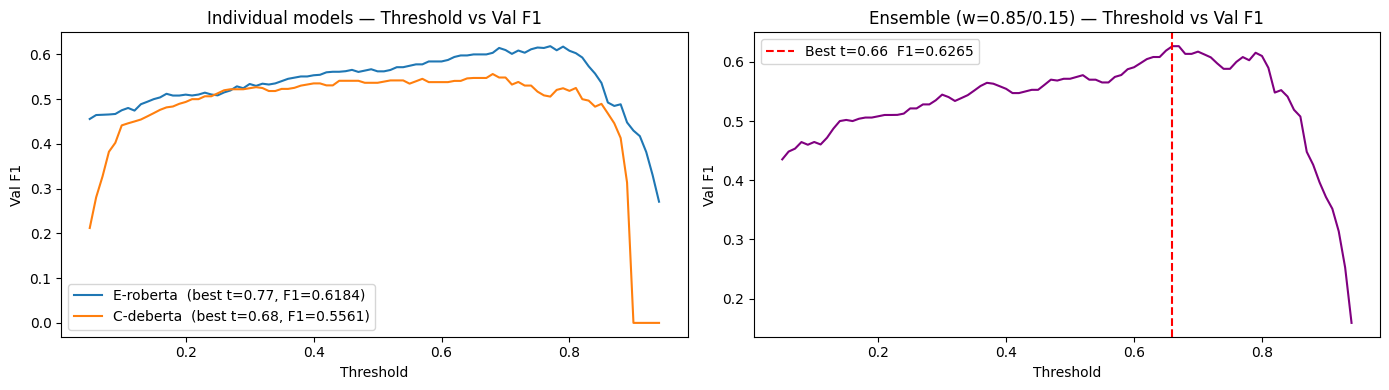

In [10]:
def _load_model_and_get_probs(model_dir, dataset, batch_size=16):
    """Load a saved checkpoint, build a DataLoader with its tokenizer, run inference."""
    tok = AutoTokenizer.from_pretrained(model_dir)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE)

    def _col(batch, _t=tok):
        texts  = [b["text"] for b in batch]
        labels = [b["label"] for b in batch] if "label" in batch[0] else None
        enc = _t(texts, padding=True, truncation=True,
                 max_length=MAX_LENGTH, return_tensors="pt")
        if labels is not None:
            enc["labels"] = torch.tensor(labels, dtype=torch.long)
        return enc

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=_col)
    probs, labels, _ = evaluate(mdl, loader)

    del mdl
    gc.collect(); torch.cuda.empty_cache()
    return probs, labels, tok


# ── Collect val probs from best seed of each model ───────────────────────────────────
val_probs_per_model = {}
val_labels = None

for cfg in ENSEMBLE_CONFIGS:
    tag = cfg["tag"]
    model_dir = best_seed[tag]["dir"]
    print(f"Loading {tag} (seed={best_seed[tag]['seed']}) from {model_dir} ...")
    probs, labels, _ = _load_model_and_get_probs(model_dir, val_dataset)
    val_probs_per_model[tag] = probs
    if val_labels is None:
        val_labels = labels
    print(f"  {tag} val F1@0.5 = {f1_score(labels, (probs >= 0.5).astype(int), pos_label=1, zero_division=0):.4f}")

# ── Grid search: ensemble weight w and threshold t ───────────────────────────────
tags = list(val_probs_per_model.keys())
probs_a = val_probs_per_model[tags[0]]  # E-roberta
probs_b = val_probs_per_model[tags[1]]  # C-deberta

BEST_W, BEST_THRESHOLD, best_ens_f1 = 0.5, 0.5, 0.0

for w in np.arange(0.0, 1.01, 0.05):
    combined = w * probs_a + (1.0 - w) * probs_b
    for t in np.arange(0.10, 0.90, 0.01):
        f1 = f1_score(val_labels, (combined >= t).astype(int), pos_label=1, zero_division=0)
        if f1 > best_ens_f1:
            BEST_W, BEST_THRESHOLD, best_ens_f1 = float(w), float(t), f1

ensemble_val_probs = BEST_W * probs_a + (1.0 - BEST_W) * probs_b

print(f"\nOptimal weight: {tags[0]}={BEST_W:.2f}, {tags[1]}={1-BEST_W:.2f}")
print(f"Optimal threshold: {BEST_THRESHOLD:.2f}")
print(f"Ensemble val F1: {best_ens_f1:.4f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
thresholds = np.arange(0.05, 0.95, 0.01)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].set_title("Individual models — Threshold vs Val F1")
for tag, probs in val_probs_per_model.items():
    f1s = [f1_score(val_labels, (probs >= t).astype(int), pos_label=1, zero_division=0)
           for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    axes[0].plot(thresholds, f1s, label=f"{tag}  (best t={best_t:.2f}, F1={max(f1s):.4f})")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Val F1")
axes[0].legend()

ens_f1s = [f1_score(val_labels, (ensemble_val_probs >= t).astype(int), pos_label=1, zero_division=0)
           for t in thresholds]
axes[1].set_title(f"Ensemble (w={BEST_W:.2f}/{1-BEST_W:.2f}) — Threshold vs Val F1")
axes[1].plot(thresholds, ens_f1s, color="purple")
axes[1].axvline(BEST_THRESHOLD, color="red", linestyle="--",
                label=f"Best t={BEST_THRESHOLD:.2f}  F1={best_ens_f1:.4f}")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Val F1")
axes[1].legend()

plt.tight_layout(); plt.show()

## 6. Evaluation on Held-out Test (Official Dev Set)

We evaluate the **ensemble** (and each individual model) on the official dev set using the threshold tuned above.

Loading weights: 100%|████████████████████| 201/201 [00:00<00:00, 782.31it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]


Loading weights: 100%|█████████████████████████████████████████████| 202/202 [00:00<00:00, 720.43it/s, Materializing param=pooler.dense.weight]


── Individual model Test F1 ──
  E-roberta:  F1@0.50=0.5485  F1@0.66=0.5604
  C-deberta:  F1@0.50=0.4845  F1@0.66=0.4817

── Ensemble (w=0.85/0.15) ──
  Test F1 (t=0.50):                0.5563
  Test F1 (t=0.66, tuned):   0.5512

              precision    recall  f1-score   support

      No PCL       0.95      0.95      0.95      1895
         PCL       0.54      0.57      0.55       199

    accuracy                           0.91      2094
   macro avg       0.74      0.76      0.75      2094
weighted avg       0.91      0.91      0.91      2094



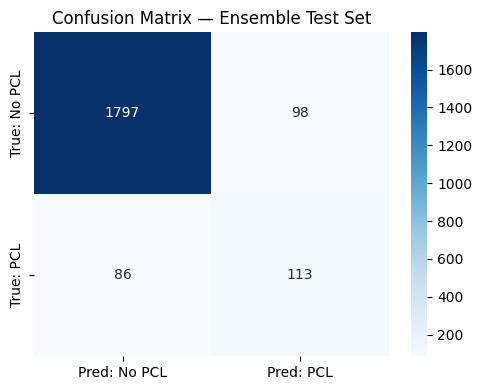

In [11]:
# ── Collect test probs from best seed of each model ──────────────────────────────────
test_probs_per_model = {}
test_labels = None

for cfg in ENSEMBLE_CONFIGS:
    tag = cfg["tag"]
    model_dir = best_seed[tag]["dir"]
    probs, labels, _ = _load_model_and_get_probs(model_dir, test_dataset)
    test_probs_per_model[tag] = probs
    if test_labels is None:
        test_labels = labels

tags = list(test_probs_per_model.keys())
ensemble_test_probs = (BEST_W * test_probs_per_model[tags[0]]
                       + (1.0 - BEST_W) * test_probs_per_model[tags[1]])
test_preds = (ensemble_test_probs >= BEST_THRESHOLD).astype(int)

# ── Individual model results ─────────────────────────────────────────────
print("── Individual model Test F1 ──")
for tag, probs in test_probs_per_model.items():
    f1_05  = f1_score(test_labels, (probs >= 0.5).astype(int), pos_label=1, zero_division=0)
    f1_tun = f1_score(test_labels, (probs >= BEST_THRESHOLD).astype(int), pos_label=1, zero_division=0)
    print(f"  {tag}:  F1@0.50={f1_05:.4f}  F1@{BEST_THRESHOLD:.2f}={f1_tun:.4f}")

# ── Ensemble results ─────────────────────────────────────────────────────
ens_f1_05  = f1_score(test_labels, (ensemble_test_probs >= 0.5).astype(int), pos_label=1, zero_division=0)
ens_f1_tun = f1_score(test_labels, test_preds, pos_label=1, zero_division=0)

print(f"\n── Ensemble (w={BEST_W:.2f}/{1-BEST_W:.2f}) ──")
print(f"  Test F1 (t=0.50):                {ens_f1_05:.4f}")
print(f"  Test F1 (t={BEST_THRESHOLD:.2f}, tuned):   {ens_f1_tun:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=["No PCL", "PCL"]))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No PCL", "Pred: PCL"],
            yticklabels=["True: No PCL", "True: PCL"])
plt.title("Confusion Matrix — Ensemble Test Set")
plt.tight_layout()
plt.show()

In [ ]:
test_df_eval = test_df.copy()
test_df_eval["pred"]  = test_preds
test_df_eval["prob"]  = ensemble_test_probs
test_df_eval["error"] = test_df_eval["label"] != test_df_eval["pred"]

# False positives: predicted PCL, actually not
fp = test_df_eval[(test_df_eval["pred"] == 1) & (test_df_eval["label"] == 0)]
# False negatives: missed PCL
fn = test_df_eval[(test_df_eval["pred"] == 0) & (test_df_eval["label"] == 1)]

print(f"False Positives: {len(fp)}  |  False Negatives: {len(fn)}")
print()
print("── 5 False Positives (predicted PCL, was No PCL) ──")
for _, row in fp.nlargest(5, "prob").iterrows():
    print(f"  [{row['prob']:.2f}] {row['text'][:120]}...")
    print()

print("── 5 False Negatives (missed PCL) ──")
for _, row in fn.nsmallest(5, "prob").iterrows():
    print(f"  [{row['prob']:.2f}] [{row['orig_label']}] {row['text'][:120]}...")
    print()

False Positives: 98  |  False Negatives: 86

── 5 False Positives (predicted PCL, was No PCL) ──
  [0.96] "Adopt a Mission serves as a platform for the church and for likeminded people to reach out to unemployed families in th...

  [0.95] "But more than taking personal strength from the heroines of Philippine culture , Alma finds greater inspiration in bein...

  [0.94] Jesus begins his teaching in Matthew with the Sermon on the Mount . One group he blesses is those in need of comfort , B...

  [0.94] """ Your personal leadership has been critical to addressing the plight of the Rohingya who fled to safety in your count...

  [0.93] His friends at the Chevron want people to know he was n't just a faceless homeless person . He was their friend and thei...

── 5 False Negatives (missed PCL) ──
  [0.01] [2] A top health official said today that the government could consider subsidies to help poor families pay for healthy food...

  [0.01] [3] Cheung said 20 disabled undergraduate student

## 7. Generate Submission Files

`dev.txt` — one prediction per line for the official dev set (2,094 lines).  
`test.txt` — one prediction per line for the official unlabelled test set (3,832 lines).  

Both files go in the repo root for leaderboard submission.

In [13]:
def _ensemble_probs_weighted(dataset, batch_size=16):
    """Return weighted positive-class probs from best-seed ensemble members."""
    all_probs = {}
    for cfg in ENSEMBLE_CONFIGS:
        tag = cfg["tag"]
        model_dir = best_seed[tag]["dir"]
        tok = AutoTokenizer.from_pretrained(model_dir)
        mdl = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE)
        def _col(batch, _t=tok):
            texts = [b["text"] for b in batch]
            enc = _t(texts, padding=True, truncation=True,
                     max_length=MAX_LENGTH, return_tensors="pt")
            return enc
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=_col)
        mdl.eval()
        probs = []
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                logits = mdl(**batch).logits
                probs.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
        all_probs[tag] = np.array(probs)
        del mdl; gc.collect(); torch.cuda.empty_cache()
    tags = list(all_probs.keys())
    return BEST_W * all_probs[tags[0]] + (1.0 - BEST_W) * all_probs[tags[1]]


# ── dev.txt: official dev set (our test split; we have labels) ───────────────
dev_preds = (ensemble_test_probs >= BEST_THRESHOLD).astype(int)
with open("../dev.txt", "w") as f:
    f.write("\n".join(map(str, dev_preds)) + "\n")
print(f"dev.txt written: {len(dev_preds)} lines  |  PCL predicted: {dev_preds.sum()}")

# ── test.txt: unlabelled official test set ───────────────────────────────
submit_dataset = PCLDataset(submit_df["input_text"].tolist())
submit_probs   = _ensemble_probs_weighted(submit_dataset)
submit_preds   = (submit_probs >= BEST_THRESHOLD).astype(int)
with open("../test.txt", "w") as f:
    f.write("\n".join(map(str, submit_preds)) + "\n")
print(f"test.txt written: {len(submit_preds)} lines  |  PCL predicted: {submit_preds.sum()}")

assert len(submit_preds) == 3832, "test.txt must have exactly 3,832 lines"

dev.txt written: 2094 lines  |  PCL predicted: 211


Loading weights: 100%|████████████████████| 201/201 [00:00<00:00, 771.38it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
Loading weights: 100%|█| 202/202 [00:00<00:00, 806.94it/s, Materializing param=pooler.dense.weigh


test.txt written: 3832 lines  |  PCL predicted: 343


## 8. Summary

The ensemble of **RoBERTa (E)** + **DeBERTa (C)** averages their positive-class
probabilities and uses a single tuned threshold. Compare the ensemble F1 to the
individual model F1s printed above to verify the improvement.

In [ ]:
print("── Final comparison ──")
for tag, info in best_seed.items():
    test_f1 = f1_score(test_labels,
                       (test_probs_per_model[tag] >= BEST_THRESHOLD).astype(int),
                       pos_label=1, zero_division=0)
    print(f"  {tag:12s}  seed={info['seed']}  val F1*={info['f1']:.4f}  test F1@{BEST_THRESHOLD:.2f}={test_f1:.4f}")

print(f"  {'ENSEMBLE':12s}  w={BEST_W:.2f}/{1-BEST_W:.2f}  val F1*={best_ens_f1:.4f}  test F1@{BEST_THRESHOLD:.2f}={ens_f1_tun:.4f}")

── Final comparison ──
  E-roberta     seed=123  val F1*=0.6184  test F1@0.66=0.5604
  C-deberta     seed=42  val F1*=0.5561  test F1@0.66=0.4817
  ENSEMBLE      w=0.85/0.15  val F1*=0.6265  test F1@0.66=0.5512
